In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
pd.options.display.max_columns=None
import warnings


In [4]:
df = pd.read_csv('/kaggle/input/powerlifting-data/powerlifting_dataset.csv')
df.head()

,Lifter Name,Age,Weight Class,Lift Type,Amount Lifted (kg)
0,Jessica Wilson,46,59 kg,Bench Press,269
1,John Doe,60,83 kg,Bench Press,179
2,Emily Davis,41,105 kg,Bench Press,235
3,Emily Davis,33,66 kg,Squat,359
4,Laura Taylor,56,74 kg,Deadlift,221


In [6]:
df.dtypes

Lifter Name           object
Age                    int64
Weight Class          object
Lift Type             object
Amount Lifted (kg)     int64
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Lifter Name         3000 non-null   object
 1   Age                 3000 non-null   int64 
 2   Weight Class        3000 non-null   object
 3   Lift Type           3000 non-null   object
 4   Amount Lifted (kg)  3000 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 117.3+ KB


In [9]:
df.columns

Index(['Lifter Name', 'Age', 'Weight Class', 'Lift Type',
       'Amount Lifted (kg)'],
      dtype='object')

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,3000.0,41.064000,13.682628,18.0,29.00,41.0,53.00,64.0
Amount Lifted (kg),3000.0,250.332667,86.281208,100.0,176.75,250.0,325.25,399.0


In [14]:
df.isnull().notnull()/len(df*100)

,Lifter Name,Age,Weight Class,Lift Type,Amount Lifted (kg)
0,0.000333,0.000333,0.000333,0.000333,0.000333
1,0.000333,0.000333,0.000333,0.000333,0.000333
2,0.000333,0.000333,0.000333,0.000333,0.000333
3,0.000333,0.000333,0.000333,0.000333,0.000333
4,0.000333,0.000333,0.000333,0.000333,0.000333
...,...,...,...,...,...
2995,0.000333,0.000333,0.000333,0.000333,0.000333
2996,0.000333,0.000333,0.000333,0.000333,0.000333
2997,0.000333,0.000333,0.000333,0.000333,0.000333
2998,0.000333,0.000333,0.000333,0.000333,0.000333


In [16]:
df.shape

(3000, 5)

In [19]:
df.corr

<bound method DataFrame.corr of          Lifter Name  Age Weight Class    Lift Type  Amount Lifted (kg)
0     Jessica Wilson   46        59 kg  Bench Press                 269
1           John Doe   60        83 kg  Bench Press                 179
2        Emily Davis   41       105 kg  Bench Press                 235
3        Emily Davis   33        66 kg        Squat                 359
4       Laura Taylor   56        74 kg     Deadlift                 221
...              ...  ...          ...          ...                 ...
2995        John Doe   46        74 kg  Bench Press                 246
2996      Daniel Lee   39         Open     Deadlift                 244
2997    Sarah Thomas   62         Open        Squat                 148
2998     Chris Brown   32        93 kg  Bench Press                 333
2999      Daniel Lee   22        83 kg     Deadlift                 280

[3000 rows x 5 columns]>

In [25]:
df.index

RangeIndex(start=0, stop=3000, step=1)

In [29]:
df.kurtosis

<bound method DataFrame.kurt of          Lifter Name  Age Weight Class    Lift Type  Amount Lifted (kg)
0     Jessica Wilson   46        59 kg  Bench Press                 269
1           John Doe   60        83 kg  Bench Press                 179
2        Emily Davis   41       105 kg  Bench Press                 235
3        Emily Davis   33        66 kg        Squat                 359
4       Laura Taylor   56        74 kg     Deadlift                 221
...              ...  ...          ...          ...                 ...
2995        John Doe   46        74 kg  Bench Press                 246
2996      Daniel Lee   39         Open     Deadlift                 244
2997    Sarah Thomas   62         Open        Squat                 148
2998     Chris Brown   32        93 kg  Bench Press                 333
2999      Daniel Lee   22        83 kg     Deadlift                 280

[3000 rows x 5 columns]>

In [31]:
df.skew

<bound method DataFrame.skew of          Lifter Name  Age Weight Class    Lift Type  Amount Lifted (kg)
0     Jessica Wilson   46        59 kg  Bench Press                 269
1           John Doe   60        83 kg  Bench Press                 179
2        Emily Davis   41       105 kg  Bench Press                 235
3        Emily Davis   33        66 kg        Squat                 359
4       Laura Taylor   56        74 kg     Deadlift                 221
...              ...  ...          ...          ...                 ...
2995        John Doe   46        74 kg  Bench Press                 246
2996      Daniel Lee   39         Open     Deadlift                 244
2997    Sarah Thomas   62         Open        Squat                 148
2998     Chris Brown   32        93 kg  Bench Press                 333
2999      Daniel Lee   22        83 kg     Deadlift                 280

[3000 rows x 5 columns]>

<Axes: >

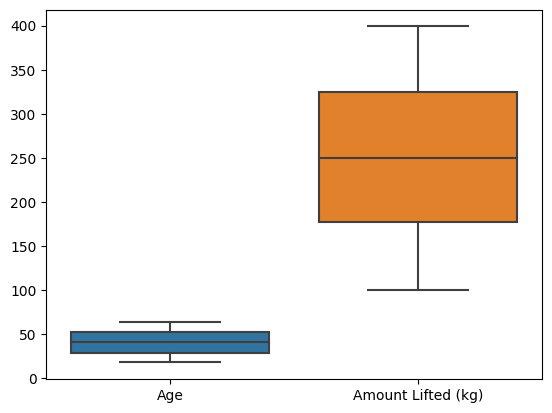

In [32]:
sns.boxplot(df)

<Axes: >

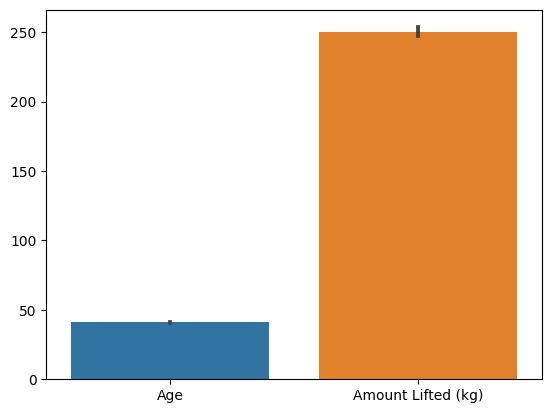

In [33]:
sns.barplot(df)

<Axes: >

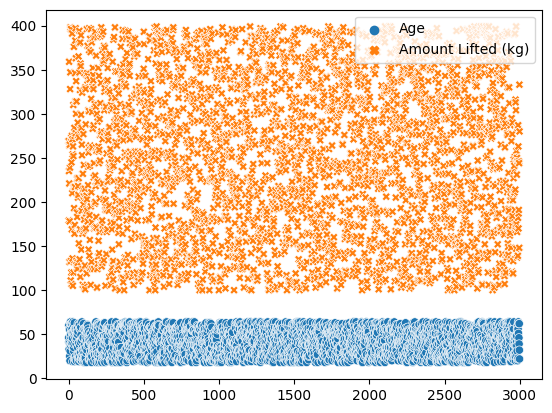

In [34]:
sns.scatterplot(df)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: >

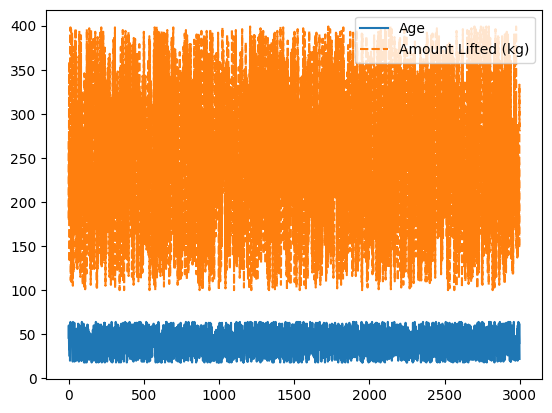

In [35]:
sns.lineplot(df)

<Axes: >

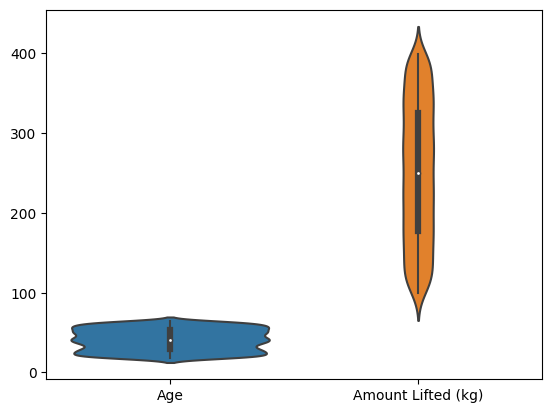

In [36]:
sns.violinplot(df)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


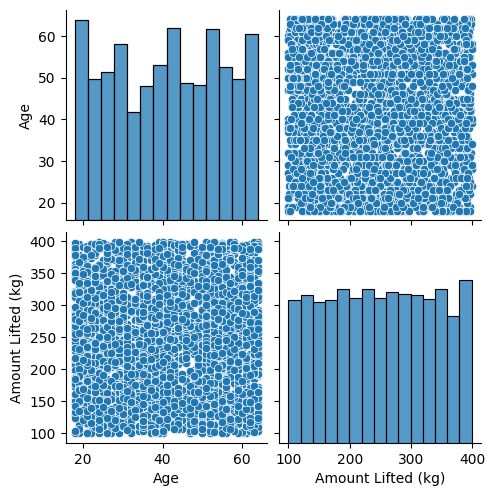

In [37]:
sns.pairplot(df)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

<Axes: ylabel='Density'>

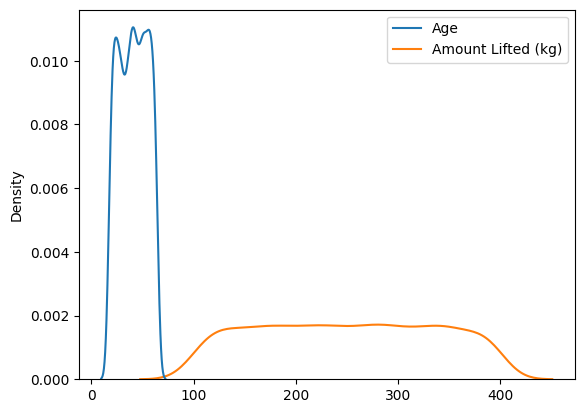

In [39]:
sns.kdeplot(df)

In [47]:
cat_cols = df.select_dtypes(include='object')

In [49]:
for i in cat_cols:
    (df.value_counts(i))
    print('\n')
    print('_'*50)



__________________________________________________


__________________________________________________


__________________________________________________


In [50]:
num_cols = df.select_dtypes(include='number')

In [51]:
for i in num_cols:
    (df.value_counts(i))
    print('\n')
    print('_'*50)



__________________________________________________


__________________________________________________


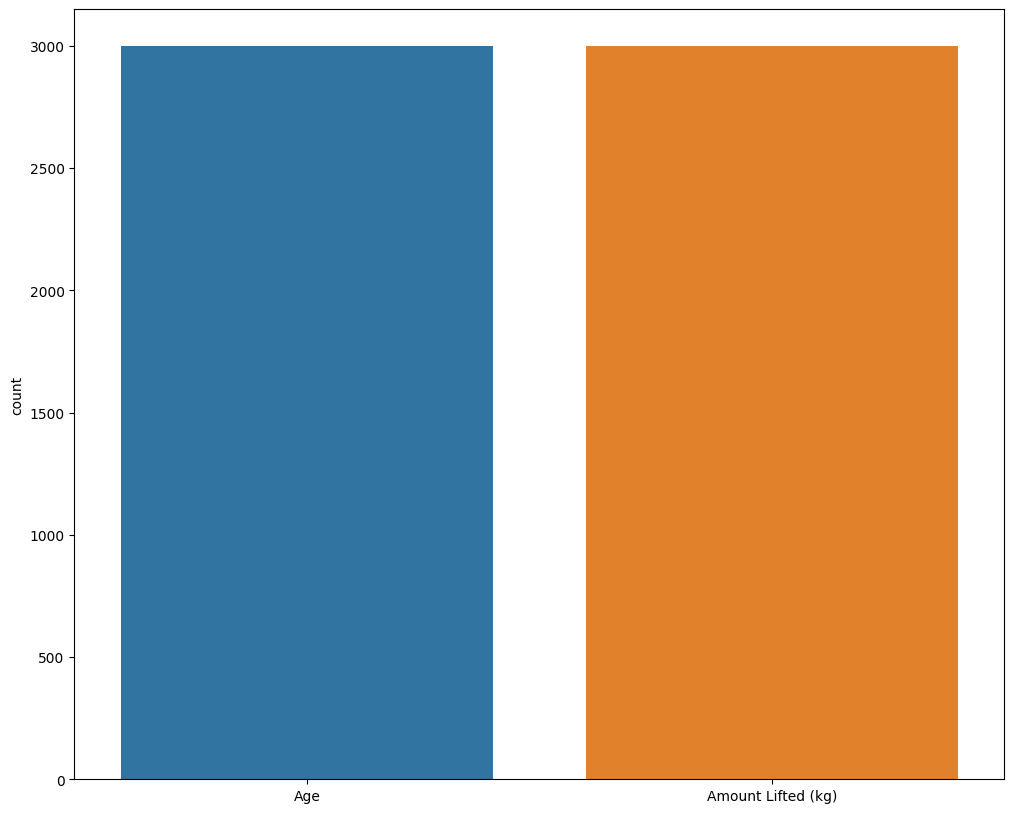

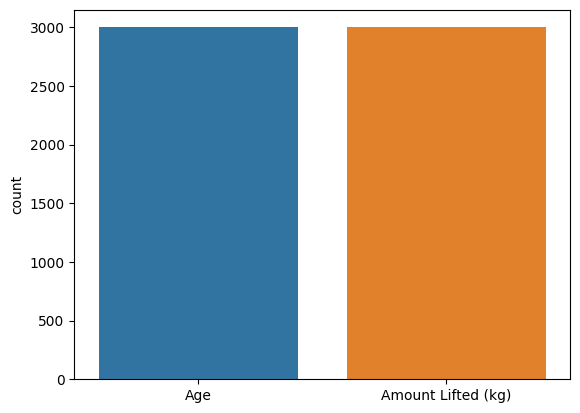

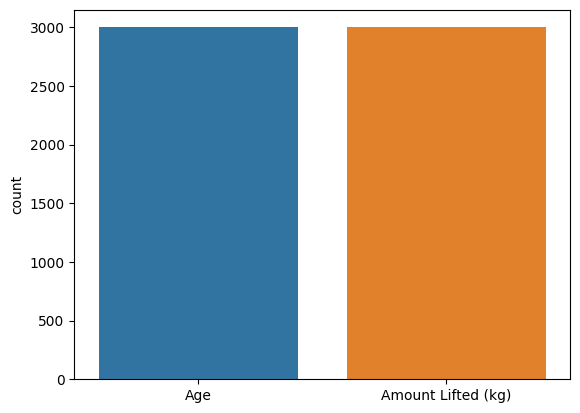

In [68]:
plt.figure(figsize=(12,10))
cat_cols = df.select_dtypes(include='object')
for i in cat_cols:
    
    sns.countplot(data=df)
    x = i
    print('\n')
    plt.show()

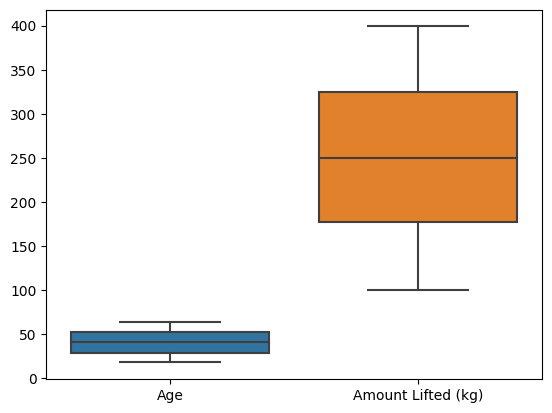

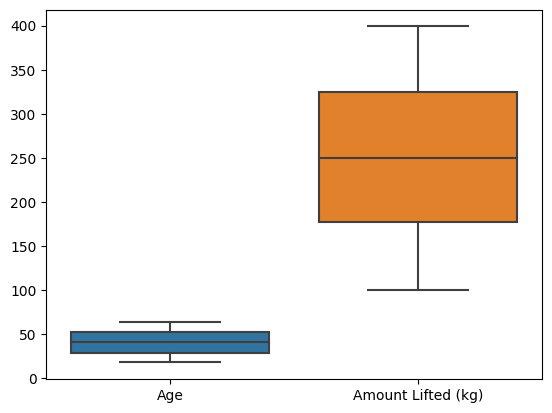

In [67]:
plt.Figure(figsize=(12,9))
num_cols = df.select_dtypes(include='number')
for i in num_cols:
    sns.boxplot(data=df)
    print('\n')
    plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

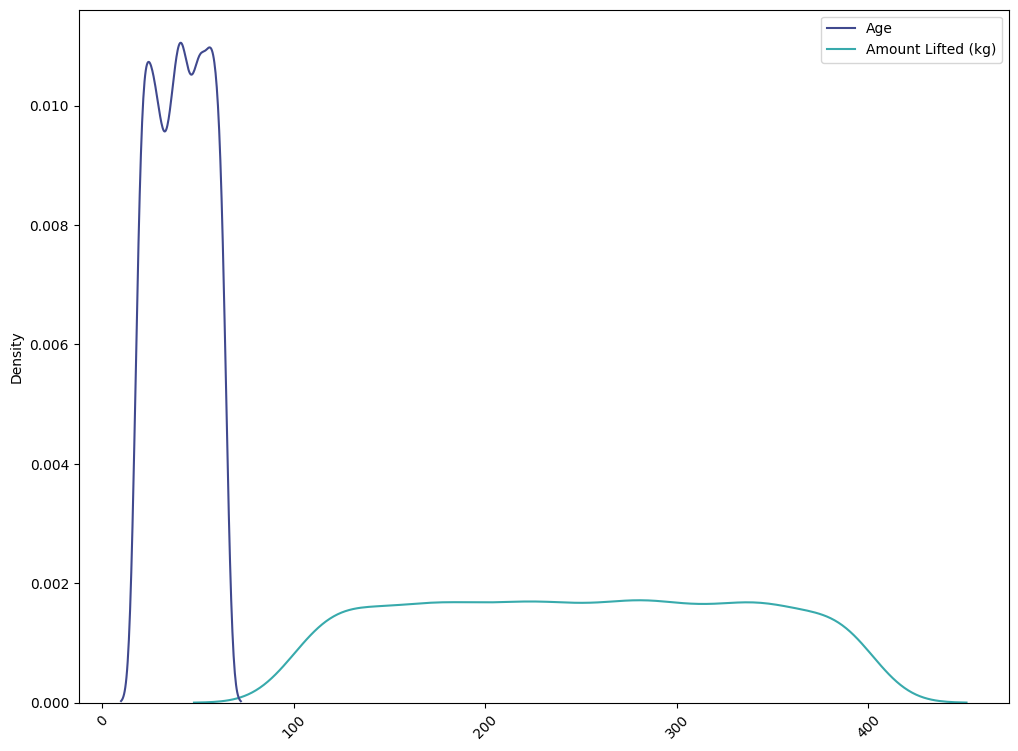

In [70]:
plt.figure(figsize=(12,9))
sns.kdeplot(data=df,palette='mako');
plt.xticks(rotation=45);
plt.show()

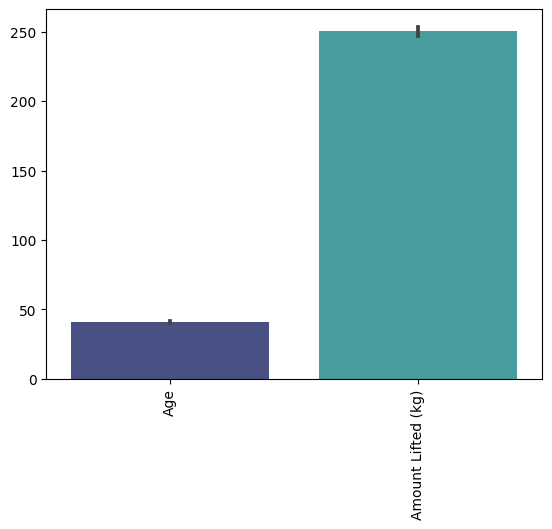

In [76]:
sns.barplot(data=df,palette='mako');
plt.xticks(rotation=90)
plt.show()

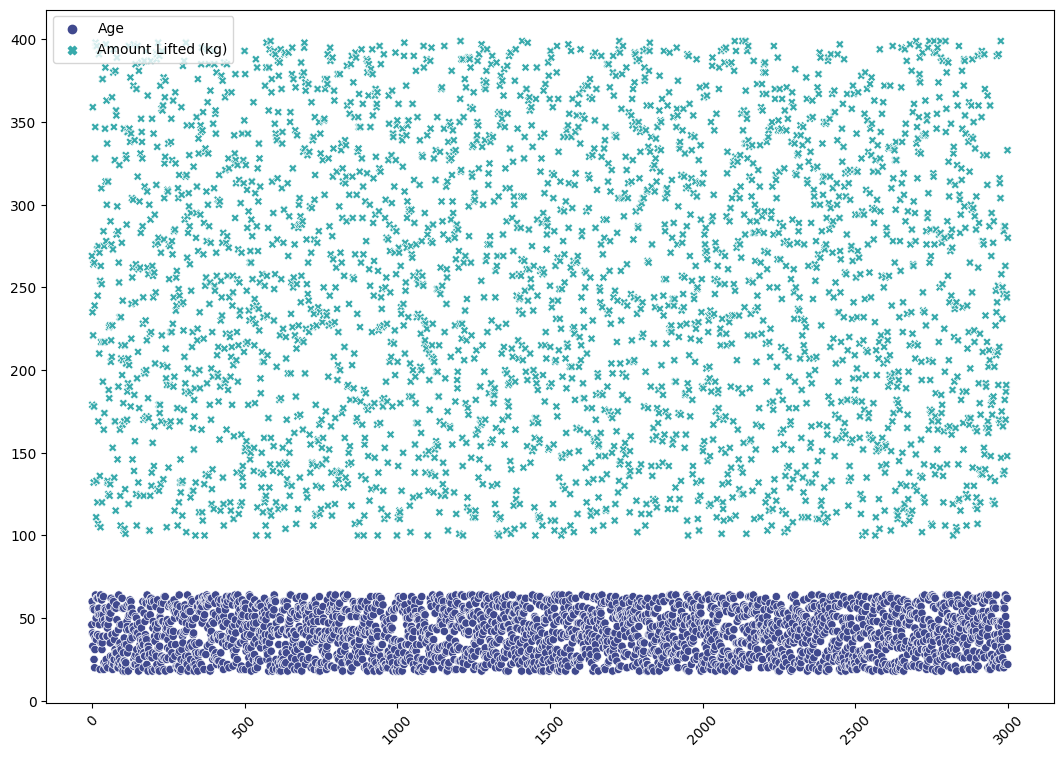

In [77]:
plt.figure(figsize=(13,9))
sns.scatterplot(data=df,palette='mako');
plt.xticks(rotation=45);
plt.show()

In [79]:
df.shape

(3000, 5)

In [85]:
df.head()

,Lifter Name,Age,Weight Class,Lift Type,Amount Lifted (kg)
0,Jessica Wilson,46,59 kg,Bench Press,269
1,John Doe,60,83 kg,Bench Press,179
2,Emily Davis,41,105 kg,Bench Press,235
3,Emily Davis,33,66 kg,Squat,359
4,Laura Taylor,56,74 kg,Deadlift,221
